# Cluster Sentences: Find communities of sentences that are highly similar to each other.

This notebook looks into techniques for defining clusters and their visualisation.
- Same sentence selection was used that was used for making the graph.
- Identify clusters with 'fast clustering' based on cosine similarity. (= `community_SBERT`)
- Visualise clusters 
  - in a 2D plane (with PCA, UMAP, and graph),
  - in wordclouds.

### Settings

In [1]:
# Experiment name
experiment_name = "free_1000_251013_pest_PD"
graph_file = f"graph_thres_0_75_{experiment_name}.pickle"

# Thresholds
community_threshold = 0.75
min_community_size = 50

# Path where to save figures
save_figs = False
path_to_save_fig = "img"

# For consistent graph plotting
seed = 42

## Initalisation

### Imports

In [2]:
from pathlib import Path
import pickle
import pandas as pd
import numpy as np
from sentence_transformers import util

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from umap import UMAP
import networkx as nx

# https://amueller.github.io/word_cloud/
from wordcloud import WordCloud
from wordcloud import STOPWORDS

import nltk
import math

/homes/jbeenen/venv/graduation_3_13_5/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-01-16 14:09:41.060203: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-16 14:09:41.128488: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-16 14:09:47.142015: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You m

### Functions

In [3]:
# For normalizing the vectors:
# function of getting magnitude/length/norm
def get_norm(matrix):
    """Calculate the norm of a vector"""
    norm = np.sqrt(
        np.sum(
            np.power(
                matrix, 
                2
            ),
            axis=1
        )
    )

    return norm

# function to divide vector by norm
# (..probably there is a numpy function for it.. but i failed to find it)
def normalize(matrix, scales):
    """Divide elements in matrix by given scale"""
    return np.array([vector / scales[idx] for idx, vector in enumerate(matrix)])

In [4]:
def plot_clusters(embed, df_vector_labels, column):
    # get unique colours
    colours = sns.color_palette("nipy_spectral", df_vector_labels[column].nunique())

    for idx, val in enumerate(sorted(df_vector_labels[column].unique())):
        projection = embed[df_vector_labels[column] == val]
        plt.scatter(projection.T[0], projection.T[1], alpha=0.1, c=colours[idx], label= val)
    plt.title(f"Coloured by {column}")

In [5]:
def plot_graph(G, pos, vector_labels: pd.DataFrame, filter_column: str,):
    """Plot graph `G` on `pos`itions, and colors clusters by looking for node_ids based on the cluster_id in given vector_labels dataframe."""
    nx.draw_networkx_edges(G, pos, width=1, alpha= 0.1)

    # get unique colours for the unique cluster_ids
    colours = sns.color_palette("nipy_spectral", vector_labels[filter_column].nunique())

    # for cluster_id in vector_labels dataframe
    for idx, cluster_id in enumerate(np.sort(vector_labels[filter_column].unique())):
        # get list of nodes
        nodelist = vector_labels.loc[vector_labels[filter_column] == cluster_id].index.to_list()

        # if cluster_id == -1, then it is not within a called cluster, and will be colored gray.
        if cluster_id == -1:
            nx.draw_networkx_nodes(
                G,
                pos,
                nodelist= nodelist,
                node_color= "tab:gray",
                edgecolors= "tab:gray",
                node_size= 15,
                alpha= 0.1
            )

            # Empty scatter is a trick to add a legend to graph (https://stackoverflow.com/questions/60706947/how-to-add-a-legend-to-networkx-graph-based-on-node-colour)
            plt.scatter([],[], c="tab:gray", label= f'Cluster {cluster_id}')

        # color each node within the same cluster with same color. Different clusters will have different colours
        else:
            nx.draw_networkx_nodes(
                G,
                pos,
                nodelist= nodelist,
                node_color= colours[idx],
                node_size= 15,
                alpha= 0.4
            )

            # Empty scatter is a trick to add a legend to graph (https://stackoverflow.com/questions/60706947/how-to-add-a-legend-to-networkx-graph-based-on-node-colour)
            plt.scatter(
                [],[],
                c= colours[idx],
                label= cluster_id
            )

    # Add legend
    plt.legend(ncol=3,bbox_to_anchor= (2.3, 1))
    plt.tight_layout()

    plt.axis("off")

In [6]:
def create_wordcloud(sentences: list, stopwords: list = [], verbose: bool = True, collocations: bool= True):
    """Create WordCloud object, 16:9 ratio, top 100 words."""
    # Print general info
    if verbose:
        print(f"Number of sentences in wordcloud: {len(sentences)}")

    # Remove stopwords
    if len(stopwords) != 0:
        new_sentences = []
        for sent in sentences:
            for word in stopwords:
                sent = sent.replace(word, "")
            new_sentences.append(sent)
    else:
        new_sentences = sentences

    # Create WordCloud object, 16:9 ratio, top 100 words
    wordcloud = WordCloud(
        width=1600,
        height=900,
        max_words= 100,
        stopwords= STOPWORDS.update(['one', 'two', 'three', 'first', 'study', 'wa', 'ha']),
        colormap= 'PiYG',
        collocations= collocations,
    ).generate(" ".join(new_sentences)) # join words to form one long 'sentence'

    # Plot
    plt.imshow(wordcloud)
    plt.axis('off')

In [7]:
# Code written by Michiel Noback, with minor adjustments by Jennefer Beenen.
class Tokenizer:
    '''class for tokenizing text data using nltk.word_tokenize(). Author: Michiel Noback.'''
    def __init__(self, stop_words: list, min_length: int=2, lemmatize: bool=True, remove_digits: bool=True):
        self.min_length = min_length
        self.lemmatize = lemmatize
        self.stop_words = stop_words
        self.remove_digits = remove_digits

    def __call__(self, s):
        return self.tokenize_text(s)
    
    def tokenize_text(self, s):
        '''tokenizes the text data'''
        # split string into words (tokens)
        tokens = nltk.tokenize.word_tokenize(s)

        # remove short words, they're probably not useful
        tokens = [t for t in tokens if len(t) >= self.min_length]

        if self.lemmatize:
            lemmatizer = nltk.stem.WordNetLemmatizer()
            # put words into base form
            tokens = [lemmatizer.lemmatize(t) for t in tokens]

        if self.stop_words:
            # remove stopwords
            tokens = [t for t in tokens if t not in self.stop_words]
        if self.remove_digits:
            # remove any digits, i.e. "3rd edition"
            tokens = [t for t in tokens if not any(c.isdigit() for c in t)]

        return tokens
    
def get_word_counts(lists: list, tokenizer) -> dict:
    """Author: Michiel Noback."""
    counts = {}
    for abstr in lists:
        words = tokenizer.tokenize_text(abstr)
        for word in words:
            counts[word] = counts.get(word, 0) + 1
    return counts

def normalize_counts(count_dict: dict):
    "Author: Michiel Noback."
    # first pass to get totals
    word_count = 0
    for (word, count) in count_dict.items():
        word_count += count
    print(f'total word count: {word_count}')

    # second pass to normalize
    for (word, count) in count_dict.items():
        count_dict[word] = count_dict[word] / word_count
    return count_dict

def filter_word_counts(word_counts, top_n = 1000):
    '''Author: Michiel Noback. Filters low-occurring words; only keeps the top-n words'''
    filtered = dict()
    
    for i, item in enumerate(sorted(word_counts.items(), 
                                    key=lambda x: x[1], 
                                    reverse=True), 
                             start=1):
        filtered[item[0]] = item[1]
        if i == top_n:
            # may never be reached with small sets
            break
            
    return filtered

def subtract_word_counts(set1, set2, top_n=1000):
    '''set2 will be subtracted from set1. Only the top_n words in set1 will be returned. Author: Michiel Noback.'''
    set1 = set1.copy()
    for (word, _) in set2.items():
        if word in set1:
            set1[word] = set1[word] - set2[word]
    return filter_word_counts(set1, top_n)

def word_list(normalized_word_dict: dict, expand_factor: int=1000):
    """Author: Michiel Noback."""
    for (word, _) in normalized_word_dict.items():
        ## expand back to integer counts
        normalized_word_dict[word] = math.ceil(normalized_word_dict[word] * expand_factor)
    # print(normalized_word_dict)
    ## make the string
    word_list = [' '.join([word] * count) for (word, count) in normalized_word_dict.items()]
    return word_list

### Load files

In [8]:
# Filenames
embedding_file = f"embedding_{experiment_name}.pickle"
raw_corpus_file = f"corpus_{experiment_name}.csv"
meta_file = f'meta_{experiment_name}.csv'

# Load graph
with open(f"../../data/graphs/{graph_file}", 'rb') as handle:
    G = pickle.load(handle)

# Load raw corpus
df_corpus = pd.read_csv(f'../../data/corpus/{raw_corpus_file}')

# Load metadata
df_meta = pd.read_csv(f'../../data/meta/{meta_file}', index_col=0)

# Load sentence embeddings
with open(f"../../data/vectors/{embedding_file}", 'rb') as handle:
    embeddings = pickle.load(handle)

# Round to 4 decimals to compensate for float point errors.
embeddings = np.round(embeddings, decimals=4)

In [9]:
# Check if embeddings normalized,
# if not, it will be normalized:
if np.sum(get_norm(embeddings)) == embeddings.shape[0]:
    print("Embedding is already normalized. (`normalized_embeddings == embeddings`)")
    normalized_embeddings = embeddings

else:
    print("Embedding is not normalized yet.")
    print("Applying normalization.")
    normalized_embeddings = normalize(
        embeddings,
        get_norm(
            embeddings
        )
    )
    print("Normalized embedding successful created. (`normalized_embeddings != embeddings`)")

Embedding is not normalized yet.
Applying normalization.
Normalized embedding successful created. (`normalized_embeddings != embeddings`)


## Pre-processing

### Filter on only sentences that are in the graph

In [10]:
# Get indexes of sentences of interest
soi_idx = sorted(G.nodes)

embeddings = pd.DataFrame(embeddings).loc[soi_idx]
normalized_embeddings = pd.DataFrame(normalized_embeddings).loc[soi_idx]

### Get sentence_id dictionary

The cluster finding algorithm does not take the sentence_id, but will return the 'enumarate_id' instead. Therefor a dictionary is created to retrieve the sentence_id.

In [11]:
# Get sentence_ids and enumerate_ids
sentence_ids = embeddings.index
enumerate_ids = np.arange(embeddings.shape[0])

# Get dict where enumerate_ids can be transformed to sentence_ids
enum_sent_dict = dict(zip(enumerate_ids, sentence_ids))

### Prepare metadata

In [12]:
# Replace " PD " with " parkinson disease ". (Important for generating a wordcloud)
df_corpus["sentence_text"] = df_corpus["sentence_text"].str.replace(
    "PD",
    "parkinson's disease",
    case= True
)

In [13]:
# Join metadata of paper
df_corpus.rename(columns={'paper_name': 'pmid'}, inplace=True)

df_vector_labels = df_corpus.join(
    df_meta[['pmid', 'is_accepted', 'is_published', 'is_retracted', 'pub_year', 'cited_by_count', 'referenced_count']].set_index('pmid'),
    on='pmid',
    how='left'
)
df_vector_labels.tail()

,paper_id,pmid,head_id,head_name,paragraph_id,sentence_id,sentence_text,is_accepted,is_published,is_retracted,pub_year,cited_by_count,referenced_count
30479,151,27993598,16,Acknowledgments,0,3,We also thank Mr. Gary Zenitsky for assistance...,True,True,False,2016,69,157
30480,151,27993598,17,•,0,0,Principle features of various Synuclein protei...,True,True,False,2016,69,157
30481,151,27993598,17,•,1,0,• New findings on metal-induced α-Syn misfoldi...,True,True,False,2016,69,157
30482,151,27993598,17,•,2,0,• Important effects of pesticides on α-Syn and...,True,True,False,2016,69,157
30483,151,27993598,18,•,3,0,Role of TBI and oxidative stress on α-Syn and ...,True,True,False,2016,69,157


## Clustering

In [14]:
# NOTE: threshold of 0.75 is based on graph in 'sentence_pairs.ipynb', section '### Distribution of highest similarity scores'
enum_idx_clusters = util.community_detection(
    embeddings.to_numpy(), 
    min_community_size= min_community_size, 
    threshold= community_threshold
)

# Change enumerate_id to sentence_id
sent_idx_clusters = [[enum_sent_dict[enum_id] for enum_id in comm_list] for comm_list in enum_idx_clusters]

In [15]:
all_sentences = [sent for clique in sent_idx_clusters for sent in clique]
print(f"Number of clusters found: {len(sent_idx_clusters)}")
print(f"{round(len(all_sentences)/df_corpus.shape[0] * 100, 2)}% ({len(all_sentences)}/{df_corpus.shape[0]}) sentences are placed in a cluster.")

Number of clusters found: 11
3.2% (975/30484) sentences are placed in a cluster.


#### Add column `community` to df_vector_labels

In [16]:
# Add column with `cluster_id` (cluster_id == -1 when it's not assigned to a clusters)
# NOTE: The key in this case is the index of the list, since the index may have changed when removing duplicates.
df_vector_labels["community_SBERT"] = -1
for idx, clique in enumerate(sent_idx_clusters):

    # clique = [comm_vector_dict[comm_idx] for comm_idx in clique]
    df_vector_labels.loc[df_vector_labels.index.isin(clique), 'community_SBERT'] = idx

In [17]:
df_vector_labels.head()

,paper_id,pmid,head_id,head_name,paragraph_id,sentence_id,sentence_text,is_accepted,is_published,is_retracted,pub_year,cited_by_count,referenced_count,community_SBERT
0,0,17900545,0,title,0,0,EPIGALLOCATECHIN GALLATE (EGCG) POTENTIATES TH...,True,True,False,2007,83,40,-1
1,0,17900545,1,Introduction,0,0,A number of studies suggest that oxidative str...,True,True,False,2007,83,40,-1
2,0,17900545,1,Introduction,0,1,Rotenone is a complex 1 inhibitor and is one o...,True,True,False,2007,83,40,-1
3,0,17900545,1,Introduction,0,2,This pesticide increases the formation of ROS ...,True,True,False,2007,83,40,-1
4,0,17900545,1,Introduction,1,0,Plant polyphenols are commonly considered as d...,True,True,False,2007,83,40,-1


## Visualisation

In [24]:
# Make "img/" dir
Path(path_to_save_fig).mkdir(exist_ok = True)
Path("/".join([path_to_save_fig, experiment_name])).mkdir(exist_ok = True)

### 2D plots

In [ ]:
# Make dir for wordclouds
path_to_plots = "/".join([path_to_save_fig, experiment_name, f"plots_min_com_{min_community_size}"])
Path("/".join([path_to_save_fig, experiment_name])).mkdir(exist_ok = True)
Path(path_to_plots).mkdir(exist_ok = True)
print(f"Plots will be saved in: '{path_to_plots}'")

#### Plot only sentences with a similarity score >= 0.75 (PCA, UMAP, Graph)

##### PCA

In [ ]:
# Apply PCA
pca = PCA(n_components=2)
pca_embeddings = pca.fit_transform(normalized_embeddings)
pca_embeddings[:5]

In [ ]:
plot_clusters(
    pca_embeddings, 
    df_vector_labels.loc[enum_sent_dict.values()], 
    'community_SBERT'
    # 'pub_year'
)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")

plt.legend()

if save_figs:
    plt.savefig("/".join([path_to_plots, f"PCA_thres_{community_threshold}_all.png"]))
plt.show()

##### UMAP

In [ ]:
# NOTE: Takes some time... (~1 minute)

umap = UMAP(
        n_components= 2,
        n_neighbors= 8,
        metric= "cosine",
    )
umap_embeddings = umap.fit_transform(normalized_embeddings)

In [ ]:
plot_clusters(
    umap_embeddings,
    df_vector_labels.loc[enum_sent_dict.values()],
    'community_SBERT'
    # 'pub_year'
    # 'pmid'
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")

plt.legend()

if save_figs:
    plt.savefig("/".join([path_to_plots, f"UMAP_thres_{community_threshold}_all.png"]))

plt.show()

##### Graph

In [ ]:
# Create embedding of graph for plotting in 2d.
pos = nx.spring_layout(G, seed=seed) # Takes 12 minutes

In [ ]:
plot_graph(
    G, 
    pos, 
    df_vector_labels.loc[enum_sent_dict.values()],
    'community_SBERT'
)

if save_figs:
    plt.savefig("/".join([path_to_plots, f"Graph_thres_{community_threshold}_all.svg"]))

plt.show()

#### Plot only clusters

##### Pre-process (make selection on only clustered sentences)

In [25]:
# Identify indexes of sentences that are in a community_SBERT cluster
idx_in_cluster = sorted(set(df_vector_labels[df_vector_labels["community_SBERT"] != -1].index))

check1 = df_vector_labels.loc[df_vector_labels["community_SBERT"] != -1, "community_SBERT"].unique()
check1

array([ 0,  2, 10,  1,  7,  3,  9,  4,  6,  8,  5])

In [26]:
# CHECK IF CORRECT
# Select only nodes that are assigned to a cluster
selected_normalized_embeddings = normalized_embeddings.loc[idx_in_cluster]

# This should have the same as print of above
check2 = df_vector_labels.loc[list(idx_in_cluster), "community_SBERT"].unique()
check2

# Is True?
set(check1) == set(check2)

True

##### PCA

In [ ]:
# Apply PCA
pca = PCA(n_components=2)
pca_embeddings = pca.fit_transform(selected_normalized_embeddings)
pca_embeddings[:5]

In [ ]:
plot_clusters(
    pca_embeddings, 
    df_vector_labels.loc[idx_in_cluster], 
    'community_SBERT'
    # 'pub_year'
)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")

plt.legend()

if save_figs:
    plt.savefig("/".join([path_to_plots, f"PCA_thres_{community_threshold}_only_clusters.png"]))
plt.show()

##### UMAP

In [ ]:
# NOTE: Takes some time... (~9 sec.)
umap = UMAP(
        n_components= 2,
        n_neighbors= 8, 
        metric= "cosine",
    )
umap_embeddings = umap.fit_transform(selected_normalized_embeddings)

In [ ]:
plot_clusters(
    umap_embeddings,
    df_vector_labels.loc[idx_in_cluster],
    'community_SBERT'
    # 'pub_year'
    # 'pmid'
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")

plt.legend(title= "Clusters")
plt.title("UMAP of clustered sentences")

if save_figs:
    plt.savefig("/".join([path_to_plots, f"UMAP_thres_{community_threshold}_only_clusters.png"]))

plt.show()

##### Graph: preprocessing

In [27]:
# Back-up G
VOI_G = G.copy()

In [28]:
# Check process
print(f"Number of nodes before selection: {len(set(VOI_G.nodes))}")

Number of nodes before selection: 15886


In [29]:
print(f"Number of sentences that are in a cluster: {len(set(idx_in_cluster))}")

Number of sentences that are in a cluster: 975


In [30]:
nodes_to_remove = set(VOI_G.nodes) - set(idx_in_cluster)
print(f"Number of nodes to remove: {len(nodes_to_remove)}")

Number of nodes to remove: 14911


In [31]:
# Remove nodes that are not in a cluster
for node_tr in nodes_to_remove:
    VOI_G.remove_node(node_tr)

print(f"New number of nodes: {len(set(VOI_G.nodes))}")

# Check if all went OK
print(f"Only sentences that are in a cluster are now in graph: {set(VOI_G.nodes) == set(idx_in_cluster)}")

New number of nodes: 975
Only sentences that are in a cluster are now in graph: True


##### Graph: plotting

In [ ]:
# Create embedding of graph for plotting in 2d.
pos = nx.spring_layout(VOI_G, seed=seed) # Takes 3 sec.

In [ ]:
plot_graph(
    VOI_G, 
    pos, 
    df_vector_labels.loc[idx_in_cluster],
    'community_SBERT'
)

plt.legend(title = "Clusters", ncol=1)
plt.title("Cosine similarity graph")

if save_figs:
    plt.savefig("/".join([path_to_plots, f"Graph_thres_{community_threshold}_only_clusters.png"]))

plt.show()

### Wordclouds

In [32]:
# Create folder for wordclouds
path_to_wordcloud = "/".join([path_to_save_fig, experiment_name, f"wordclouds_min_com_{min_community_size}"])
Path(path_to_wordcloud).mkdir(exist_ok = True)
print(f"Wordclouds will be saved in: '{path_to_wordcloud}'")

Wordclouds will be saved in: 'img/free_1000_251013_pest_PD/wordclouds_min_com_50'


#### General wordcloud

Number of sentences in wordcloud: 29509


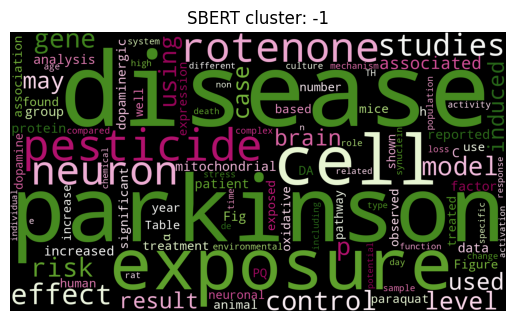

/tmp/ipykernel_2518631/1871131073.py:58: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_cluster_meta = pd.concat([df_cluster_meta, new_row], axis=0)#.reset_index(drop=True)


Number of sentences in wordcloud: 203


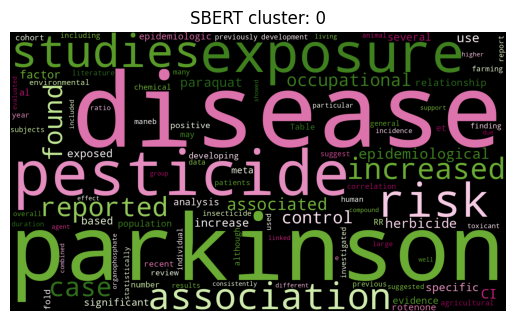

Number of sentences in wordcloud: 157


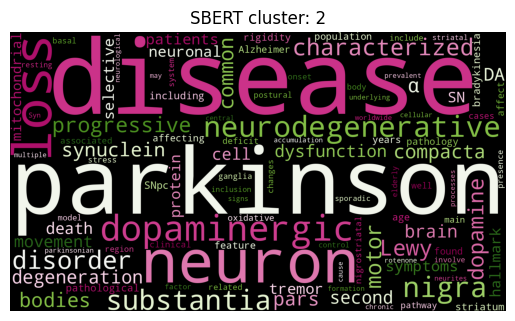

Number of sentences in wordcloud: 50


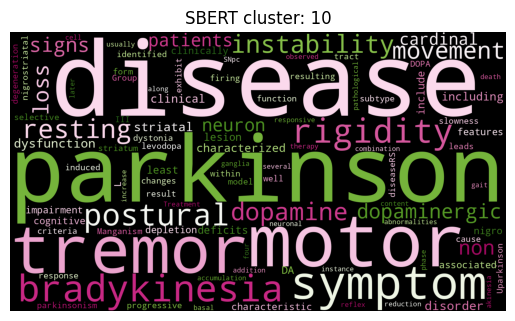

Number of sentences in wordcloud: 179


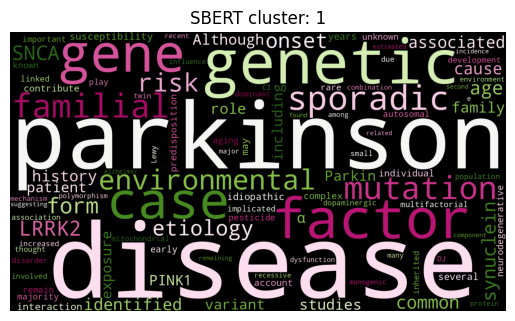

Number of sentences in wordcloud: 54


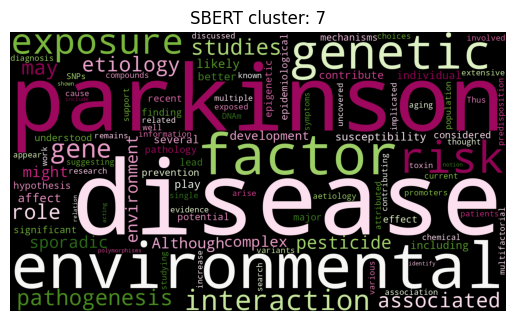

Number of sentences in wordcloud: 57


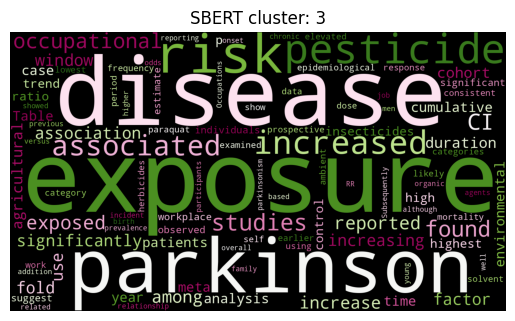

Number of sentences in wordcloud: 52


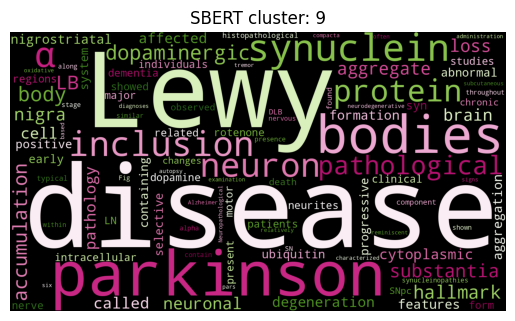

Number of sentences in wordcloud: 57


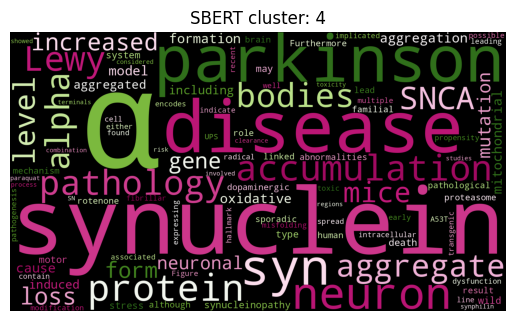

Number of sentences in wordcloud: 55


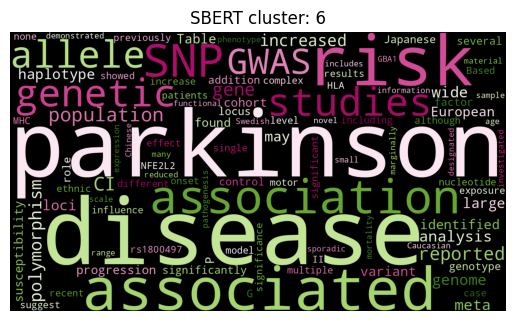

Number of sentences in wordcloud: 54


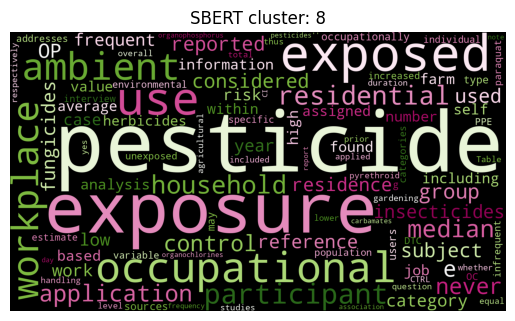

Number of sentences in wordcloud: 57


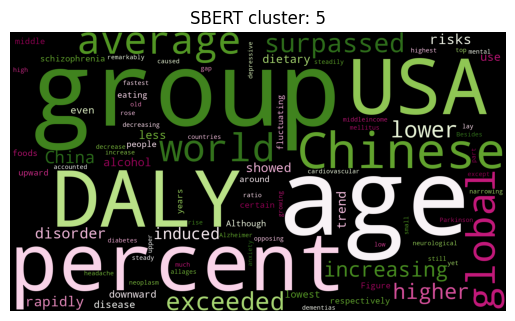

,SBERT cluster,Sentence count,Paper count,Published (%),Largest contributor (PMID),Largest contributor (%),If even distributed (%)
0,-1,29509,152,98.773256,21626386,3.639568,0.657895
0,0,203,70,98.522167,21626386,7.389163,1.428571
0,2,157,87,99.363057,20926834,4.458599,1.149425
0,10,50,34,100.000000,21486284,12.000000,2.941176
0,1,179,72,97.206704,21626386,7.821229,1.388889
0,7,54,38,92.592593,23055790,7.407407,2.631579
0,3,57,31,100.000000,21626386,8.771930,3.225806
0,9,52,26,100.000000,21626386,11.538462,3.846154
0,4,57,33,100.000000,30214392,12.280702,3.030303
0,6,55,18,100.000000,27148593,18.181818,5.555556


In [ ]:
# df for collecting meta data
columns = [
    "SBERT cluster",
    "Sentence count",
    "Paper count",
    "Published (%)",
    "Largest contributor (PMID)",
    "Largest contributor (%)",
    "If even distributed (%)"
]

df_cluster_meta = pd.DataFrame(columns= columns)


for cluster_id in df_vector_labels['community_SBERT'].unique():
    # Select column 'sentence_text' on given cluster_id
    sentences = df_vector_labels.loc[
                df_vector_labels['community_SBERT'] == cluster_id,
                'sentence_text'
            ].values

    # Plot wordcloud
    create_wordcloud(
        sentences= sentences,
        # stopwords= ["parkinson's disease", "pesticides", "parkinson", "disease", "pesticide", ],
        collocations= False,
    )

    # Add title, save and show figure
    plt.title(f"SBERT cluster: {cluster_id}")

    if save_figs:
        plt.savefig("/".join([path_to_wordcloud, f"SBERT_cluster_{cluster_id}.png"]),
                    dpi= 600,
                    bbox_inches= "tight"
        )
    plt.show()

    #### Get meta data
    # Get meta data for title
    df_cluster_selection = df_vector_labels[df_vector_labels['community_SBERT'] == cluster_id]
    largest_contributor = df_cluster_selection["pmid"].value_counts(normalize=True)

    new_values = [
        [cluster_id],
        [len(sentences)],
        [df_vector_labels.loc[df_vector_labels['community_SBERT'] == cluster_id, 'pmid'].nunique()],
        [df_cluster_selection.is_published.value_counts(normalize=True)[True] *100],
        [largest_contributor.index[0]],
        [largest_contributor.values[0] * 100],
        [100 / df_cluster_selection['pmid'].nunique()],
    ]

    new_row = pd.DataFrame(dict(zip(columns, new_values)))

    df_cluster_meta = pd.concat([df_cluster_meta, new_row], axis=0)

if save_figs:
    df_cluster_meta.sort_values(by= "SBERT cluster").to_csv("/".join([path_to_wordcloud, "cluster_meta.csv"]))
        
df_cluster_meta


In [ ]:
# Sort generated meta data table
df_cluster_meta.sort_values(by= "SBERT cluster").round(2)

,SBERT cluster,Sentence count,Paper count,Published (%),Largest contributor (PMID),Largest contributor (%),If even distributed (%)
0,-1,29509,152,98.77,21626386,3.64,0.66
0,0,203,70,98.52,21626386,7.39,1.43
0,1,179,72,97.21,21626386,7.82,1.39
0,2,157,87,99.36,20926834,4.46,1.15
0,3,57,31,100.00,21626386,8.77,3.23
0,4,57,33,100.00,30214392,12.28,3.03
0,5,57,1,100.00,36698474,100.00,100.00
0,6,55,18,100.00,27148593,18.18,5.56
0,7,54,38,92.59,23055790,7.41,2.63
0,8,54,18,100.00,28779877,33.33,5.56


In [ ]:
# # Plot and save wordcloud per SBERT cluster
# for cluster_id in df_vector_labels['community_SBERT'].unique():

#     # Select column 'sentence_text' on given cluster_id
#     sentences = df_vector_labels.loc[
#                 df_vector_labels['community_SBERT'] == cluster_id,
#                 'sentence_text'
#             ].values

#     # Plot wordcloud
#     create_wordcloud(
#         sentences= sentences,
#         # stopwords= ["parkinson's disease", "pesticides", "parkinson", "disease", "pesticide", ],
#         collocations= False,
#     )

#     # Get meta data for title
#     df_cluster_selection = df_vector_labels[df_vector_labels['community_SBERT'] == cluster_id]
#     is_published = df_cluster_selection.drop_duplicates('pmid')['is_published'].value_counts()
#     largest_contributor = df_cluster_selection["pmid"].value_counts(normalize=True)

#     # Add title, save and show figure
#     plt.title(f"""SBERT cluster: {cluster_id}
# Number of sentences: {len(sentences)}
# Number of papers: {df_vector_labels.loc[df_vector_labels['community_SBERT'] == cluster_id, 'pmid'].nunique()}
# Percentage published: {(is_published.get(True,0) / is_published.sum() * 100):.2f}%
# Largest contributor: {largest_contributor.index[0]} ({largest_contributor.values[0] * 100 :.2f}%) (should be ~{100 / df_cluster_selection['pmid'].nunique():.2f}% if even distributed.)""")
    
#     if save_figs:
#         plt.savefig("/".join([path_to_wordcloud, f"SBERT_cluster_{cluster_id}.png"]),
#                     dpi= 600,
#                     bbox_inches= "tight"
#         )
#     plt.show()

#### Differential wordclouds

In [18]:
# the custom class Tokenizer can also lemmatize, and remove short words, digits and stopwords
tokenizer = Tokenizer(
    stop_words= list(STOPWORDS),
    min_length=3
)

In [ ]:
#
# df for collecting meta data
columns = [
    "SBERT cluster",
    "Sentence count",
    "Paper count",
    "Published (%)",
    "Largest contributor (PMID)",
    "Largest contributor (%)",
    "If even distributed (%)"
]

df_cluster_meta = pd.DataFrame(columns= columns)


for cluster_id in df_vector_labels['community_SBERT'].unique():

    # Select column 'sentence_text' on given cluster_id
    list_select = df_vector_labels.loc[
        df_vector_labels["community_SBERT"] == cluster_id,
        "sentence_text"
    ].values
    list_deselect = df_vector_labels.loc[
        df_vector_labels["community_SBERT"] != cluster_id,
        "sentence_text"
    ].values

    # Normalise and filter word counts
    filtered_select = filter_word_counts(
        normalize_counts(
            get_word_counts(
                list_select,
                tokenizer,
            ).copy()
        )
    )
    filtered_deselect = filter_word_counts(
        normalize_counts(
            get_word_counts(
                list_deselect,
                tokenizer,
            ).copy()
        )
    )

    # Substract word sets
    diff_select = subtract_word_counts(filtered_select, filtered_deselect)

    # Plot wordcloud
    create_wordcloud(
        word_list(
            diff_select
        ),
        collocations= False
    )

    # Add title, save and show figure
    plt.title(f"SBERT cluster: {cluster_id}")

    if save_figs:
        plt.savefig("/".join([path_to_wordcloud, f"diff_SBERT_cluster_{cluster_id}.png"]),
                    dpi= 600,
                    bbox_inches= "tight"
        )
    plt.show()

    #### Get meta data
    # Get meta data for title
    df_cluster_selection = df_vector_labels[df_vector_labels['community_SBERT'] == cluster_id]
    largest_contributor = df_cluster_selection["pmid"].value_counts(normalize=True)

    new_values = [
        [cluster_id],
        [len(sentences)],
        [df_vector_labels.loc[df_vector_labels['community_SBERT'] == cluster_id, 'pmid'].nunique()],
        [df_cluster_selection.is_published.value_counts(normalize=True)[True] *100],
        [largest_contributor.index[0]],
        [largest_contributor.values[0] * 100],
        [100 / df_cluster_selection['pmid'].nunique()],
    ]

    new_row = pd.DataFrame(dict(zip(columns, new_values)))

    df_cluster_meta = pd.concat([df_cluster_meta, new_row], axis=0)#.reset_index(drop=True)

if save_figs:
    df_cluster_meta.sort_values(by= "SBERT cluster").to_csv("/".join([path_to_wordcloud, "cluster_diff_meta.csv"]))
        
df_cluster_meta

~END~